In [15]:
import pandas as pd
import matplotlib
import ast
#matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

#폰트 설정(없으면 영문으로 나옴)
try:
    font_path = [f for f in fm.findSystemFonts() if 'NanumGothic' in f or 'Malgun' in f or 'AppleGothic' in f]
    if font_path:
        plt.rcParams['font.family'] = fm.FontProperties(fname=font_path[0]).get_name()
    else:
        plt.rcParams['font.family'] = 'DejaVu Sans'
except:
    plt.rcParams['font.family'] = 'DejaVu Sans'

plt.rcParams['axes.unicode_minus'] = False

In [16]:
funnel = pd.read_csv('../Soyun_EDA/funnel_instance.csv')#EDA 코드 돌리고 나온 파일로 하심 됩니다
full = pd.read_csv('../Soyun_EDA/final_eda.csv')

In [17]:
funnel.columns

Index(['customer_id', 'offer_id', 't_received', 'offer_type', 'instance_id',
       't_viewed', 'last_viewed', 'view_count', 't_completed',
       'last_completed', 'complete_count', 'gap_to_view', 'gap_to_complete',
       'gap_view_to_complete', 'gap_to_view_day', 'gap_to_complete_day',
       'gap_view_to_complete_day', 'is_viewed', 'is_completed',
       'completed_without_view', 'valid_view_sequence', 'offer_duration',
       'offer_type_port', 'duration_hours', 'within_duration', 'was_viewed',
       'was_completed'],
      dtype='str')

In [18]:
# 불필요 컬럼 제거
funnel = funnel.drop(columns=['offer_type_port', 'offer_duration', 'duration_hours'], errors='ignore')

print(funnel.columns)

Index(['customer_id', 'offer_id', 't_received', 'offer_type', 'instance_id',
       't_viewed', 'last_viewed', 'view_count', 't_completed',
       'last_completed', 'complete_count', 'gap_to_view', 'gap_to_complete',
       'gap_view_to_complete', 'gap_to_view_day', 'gap_to_complete_day',
       'gap_view_to_complete_day', 'is_viewed', 'is_completed',
       'completed_without_view', 'valid_view_sequence', 'within_duration',
       'was_viewed', 'was_completed'],
      dtype='str')


In [19]:
#고객 가입정보
cust_attr = (
    full[['customer_id', 'join_year', 'join_month', 'join_year_month', 'join_cohort']]
    .drop_duplicates('customer_id')
)

funnel = funnel.merge(cust_attr, on='customer_id', how='left')

In [20]:
# 오퍼 속성 병합
portfolio = (
    full[['offer_id', 'difficulty', 'reward', 'duration', 'offer_type']]
    .dropna(subset=['offer_id'])
    .drop_duplicates('offer_id')
)

funnel = funnel.merge(portfolio, on='offer_id', how='left')

# 고객 속성 병합
cust_attr = (
    full[['customer_id', 'gender', 'age_group', 'income_group',
          'join_year', 'join_month', 'join_year_month', 'join_cohort']]
    .drop_duplicates('customer_id')
)

funnel = funnel.merge(cust_attr, on='customer_id', how='left')

funnel.head()

,customer_id,offer_id,t_received,offer_type_x,instance_id,t_viewed,last_viewed,view_count,t_completed,last_completed,...,reward,duration,offer_type_y,gender,age_group,income_group,join_year_y,join_month_y,join_year_month_y,join_cohort_y
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,discount,1,NaN,NaN,NaN,576.0,576.0,...,2.0,7.0,discount,M,30대,5-7.5만,2017,4,2017-04,2017-04
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,336,informational,1,372.0,372.0,1.0,NaN,NaN,...,0.0,4.0,informational,M,30대,5-7.5만,2017,4,2017-04,2017-04
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,168,informational,1,192.0,192.0,1.0,NaN,NaN,...,0.0,3.0,informational,M,30대,5-7.5만,2017,4,2017-04,2017-04
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,408,bogo,1,456.0,456.0,1.0,414.0,414.0,...,5.0,5.0,bogo,M,30대,5-7.5만,2017,4,2017-04,2017-04
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,504,discount,1,540.0,540.0,1.0,528.0,528.0,...,2.0,10.0,discount,M,30대,5-7.5만,2017,4,2017-04,2017-04


In [21]:
funnel.columns

Index(['customer_id', 'offer_id', 't_received', 'offer_type_x', 'instance_id',
       't_viewed', 'last_viewed', 'view_count', 't_completed',
       'last_completed', 'complete_count', 'gap_to_view', 'gap_to_complete',
       'gap_view_to_complete', 'gap_to_view_day', 'gap_to_complete_day',
       'gap_view_to_complete_day', 'is_viewed', 'is_completed',
       'completed_without_view', 'valid_view_sequence', 'within_duration',
       'was_viewed', 'was_completed', 'join_year_x', 'join_month_x',
       'join_year_month_x', 'join_cohort_x', 'difficulty', 'reward',
       'duration', 'offer_type_y', 'gender', 'age_group', 'income_group',
       'join_year_y', 'join_month_y', 'join_year_month_y', 'join_cohort_y'],
      dtype='str')

In [22]:
# _x suffix 제거
funnel.columns = funnel.columns.str.replace(r'_x$', '', regex=True)

# _y 컬럼 제거
funnel = funnel.drop(columns=[c for c in funnel.columns if c.endswith('_y')], errors='ignore')

In [23]:
funnel.columns

Index(['customer_id', 'offer_id', 't_received', 'offer_type', 'instance_id',
       't_viewed', 'last_viewed', 'view_count', 't_completed',
       'last_completed', 'complete_count', 'gap_to_view', 'gap_to_complete',
       'gap_view_to_complete', 'gap_to_view_day', 'gap_to_complete_day',
       'gap_view_to_complete_day', 'is_viewed', 'is_completed',
       'completed_without_view', 'valid_view_sequence', 'within_duration',
       'was_viewed', 'was_completed', 'join_year', 'join_month',
       'join_year_month', 'join_cohort', 'difficulty', 'reward', 'duration',
       'gender', 'age_group', 'income_group'],
      dtype='str')

In [24]:
from scipy import stats

print("=" * 50)
print("[ 1막 통계 — bogo vs discount 반응 시간 ]")
print("=" * 50)

bogo_gap = funnel.loc[
    (funnel['offer_type'] == 'bogo') &
    (funnel['gap_to_complete'].notna()),
    'gap_to_complete'
]

disc_gap = funnel.loc[
    (funnel['offer_type'] == 'discount') &
    (funnel['gap_to_complete'].notna()),
    'gap_to_complete'
]

print(f"\n  bogo     완료 건수: {len(bogo_gap):,}  중앙값: {bogo_gap.median()/24:.1f}일  평균: {bogo_gap.mean()/24:.1f}일")
print(f"  discount 완료 건수: {len(disc_gap):,}  중앙값: {disc_gap.median()/24:.1f}일  평균: {disc_gap.mean()/24:.1f}일")

bogo_sample = bogo_gap.sample(min(5000, len(bogo_gap)), random_state=42)
disc_sample = disc_gap.sample(min(5000, len(disc_gap)), random_state=42)

_, p_b = stats.shapiro(bogo_sample)
_, p_d = stats.shapiro(disc_sample)

print(f"\n  정규성 검정 (Shapiro-Wilk, 최대 5000 샘플)")
print(f"  bogo p={p_b:.4f} / discount p={p_d:.4f}")
print("  → 비정규 분포 가정 시 Mann-Whitney U test 사용")

u_stat, p_val = stats.mannwhitneyu(bogo_gap, disc_gap, alternative='two-sided')

print(f"\n  Mann-Whitney U test")
print(f"  U={u_stat:.0f},  p={p_val:.2e}")

if p_val < 0.05:
    print("  → p < 0.05: 유의미한 차이 있음 ✅")
    print(f"  → bogo가 discount보다 {(disc_gap.median() - bogo_gap.median())/24:.1f}일 빠르게 완료됨")
else:
    print("  → p >= 0.05: 유의미한 차이 없음")

n1, n2 = len(bogo_gap), len(disc_gap)
r = 1 - (2 * u_stat) / (n1 * n2)

print(f"  효과 크기 (rank-biserial r) = {r:.3f}")
print(f"  → {'작음 (|r|<0.1)' if abs(r)<0.1 else '중간 (0.1≤|r|<0.3)' if abs(r)<0.3 else '큼 (|r|≥0.3)'}")

[ 1막 통계 — bogo vs discount 반응 시간 ]

  bogo     완료 건수: 15,501  중앙값: 1.8일  평균: 2.1일
  discount 완료 건수: 17,600  중앙값: 2.5일  평균: 3.0일

  정규성 검정 (Shapiro-Wilk, 최대 5000 샘플)
  bogo p=0.0000 / discount p=0.0000
  → 비정규 분포 가정 시 Mann-Whitney U test 사용

  Mann-Whitney U test
  U=107644868,  p=1.37e-241
  → p < 0.05: 유의미한 차이 있음 ✅
  → bogo가 discount보다 0.8일 빠르게 완료됨
  효과 크기 (rank-biserial r) = 0.211
  → 중간 (0.1≤|r|<0.3)


In [25]:
print("=" * 55)
print("[ stage2 — 퍼널 분석 ]")
print("=" * 55)

total_received = len(funnel)
total_viewed   = funnel['was_viewed'].sum()
total_completed = funnel['was_completed'].sum()

view_rate = total_viewed / total_received
complete_rate = total_completed / total_received
view_to_complete = total_completed / total_viewed if total_viewed > 0 else 0

print(f"\n  수신 → 열람 전환율: {view_rate*100:.1f}%")
print(f"  수신 → 완료 전환율: {complete_rate*100:.1f}%")
print(f"  열람 → 완료 전환율: {view_to_complete*100:.1f}%")

[ stage2 — 퍼널 분석 ]

  수신 → 열람 전환율: 75.7%
  수신 → 완료 전환율: 43.4%
  열람 → 완료 전환율: 57.3%


In [26]:
# -------------------------------
# 분석 2-1. 열람 안 한 고객 규모 및 특성
# -------------------------------
print("-" * 45)
print("[열람 안 한 고객 ]")
print("-" * 45)

not_viewed = funnel[funnel['was_viewed'] == 0]
print(f"\n  미열람 오퍼: {len(not_viewed):,}건  ({len(not_viewed)/total_received*100:.1f}%)")

print("\n  미열람 고객 특성 (오퍼 단위):")

print("\n  [ 연령대 ]")
nv_age = not_viewed['age_group'].value_counts(normalize=True) * 100
all_age = funnel['age_group'].value_counts(normalize=True) * 100
age_order = ['20대 미만', '20대', '30대', '40대', '50대', '60대 이상', '누락']
for a in age_order:
    nv = nv_age.get(a, 0)
    al = all_age.get(a, 0)
    diff = nv - al
    sign = '+' if diff > 0 else ''
    print(f"    {a:<8}  미열람 {nv:.1f}%  전체 {al:.1f}%  ({sign}{diff:.1f}%p)")

print("[ 소득 구간 ]")
nv_inc = not_viewed['income_group'].value_counts(normalize=True) * 100
all_inc = funnel['income_group'].value_counts(normalize=True) * 100
for i in ['누락', '5만 미만', '5-7.5만', '7.5-10만', '10만 이상']:
    nv = nv_inc.get(i, 0)
    al = all_inc.get(i, 0)
    diff = nv - al
    sign = '+' if diff > 0 else ''
    print(f"    {i:<10}  미열람 {nv:.1f}%  전체 {al:.1f}%  ({sign}{diff:.1f}%p)")

print("\n  [ 오퍼 유형별 미열람률 ]")
for otype in ['bogo', 'discount', 'informational']:
    ot = funnel[funnel['offer_type'] == otype]
    nv_rate = (ot['was_viewed'] == 0).mean() * 100
    print(f"    {otype:<15}  {nv_rate:.1f}%")

---------------------------------------------
[열람 안 한 고객 ]
---------------------------------------------

  미열람 오퍼: 18,552건  (24.3%)

  미열람 고객 특성 (오퍼 단위):

  [ 연령대 ]
    20대 미만    미열람 1.4%  전체 1.2%  (+0.2%p)
    20대       미열람 10.3%  전체 8.1%  (+2.2%p)
    30대       미열람 10.3%  전체 9.0%  (+1.3%p)
    40대       미열람 11.7%  전체 13.5%  (-1.8%p)
    50대       미열람 20.9%  전체 20.8%  (+0.1%p)
    60대 이상    미열람 34.9%  전체 34.5%  (+0.4%p)
    누락        미열람 10.3%  전체 12.8%  (-2.5%p)
[ 소득 구간 ]
    누락          미열람 10.3%  전체 12.8%  (-2.5%p)
    5만 미만       미열람 29.0%  전체 22.2%  (+6.7%p)
    5-7.5만      미열람 34.9%  전체 38.0%  (-3.1%p)
    7.5-10만     미열람 17.1%  전체 20.5%  (-3.4%p)
    10만 이상      미열람 8.7%  전체 6.4%  (+2.3%p)

  [ 오퍼 유형별 미열람률 ]
    bogo             16.6%
    discount         29.8%
    informational    28.9%


In [28]:
# ----------------------------------------
# 분석 2-2. 미인지 완료 (viewed 없이 completed)
# ----------------------------------------
print("\n" + "-" * 45)
print("[미인지 완료 분석 ]")
print("-" * 45)

unaware = funnel[funnel['completed_without_view'] == 1]
aware   = funnel[
    (funnel['was_completed'] == 1) &
    (funnel['completed_without_view'] == 0)
]

print(f" 정상 퍼널 완료 (열람→완료): {len(aware):,}건  ({len(aware)/(len(aware)+len(unaware))*100:.1f}%)")
print(f"  미인지 완료 (열람 없이 완료): {len(unaware):,}건  ({len(unaware)/(len(aware)+len(unaware))*100:.1f}%)")

# 미인지 완료 고객 특성
print("\n  미인지 완료 고객 특성:")
print("\n  [ 소득 구간 ]")
uw_inc = unaware['income_group'].value_counts(normalize=True) * 100
aw_inc = aware['income_group'].value_counts(normalize=True) * 100
for i in ['누락', '5만 미만', '5-7.5만', '7.5-10만', '10만 이상']:
    uw = uw_inc.get(i, 0)
    aw = aw_inc.get(i, 0)
    diff = uw - aw
    sign = '+' if diff > 0 else ''
    print(f"    {i:<10}  미인지 {uw:.1f}%  정상 {aw:.1f}%  ({sign}{diff:.1f}%p)")


# 미인지 완료 고객의 거래금액 비교
tx = full[full['event'] == 'transaction'][['customer_id', 'time', 'amount']]

def get_nearby_tx(completed_df, tx_df, complete_time_col='t_completed', window=24):
    merged = completed_df[['customer_id', complete_time_col]].merge(
        tx_df.rename(columns={'time': 'tx_time', 'amount': 'tx_amount'}),
        on='customer_id', how='left'
    )
    merged = merged[
        (merged['tx_time'] >= merged[complete_time_col] - window) &
        (merged['tx_time'] <= merged[complete_time_col] + window)
    ]
    return merged.groupby('customer_id')['tx_amount'].mean()

uw_tx = get_nearby_tx(unaware, tx, complete_time_col='t_completed')
aw_tx = get_nearby_tx(aware, tx, complete_time_col='t_completed')

print(f"\n  완료 전후 24시간 내 평균 거래금액:")
print(f"    미인지 완료 고객: ${uw_tx.mean():.2f}")
print(f"    정상 퍼널 고객  : ${aw_tx.mean():.2f}")

u2, p2 = stats.mannwhitneyu(uw_tx.dropna(), aw_tx.dropna(), alternative='two-sided')
print(f"\n  Mann-Whitney U test: p={p2:.4f}")
print(f"  → {'유의미한 차이 있음 ✅' if p2 < 0.05 else '유의미한 차이 없음'}")


---------------------------------------------
[미인지 완료 분석 ]
---------------------------------------------
 정상 퍼널 완료 (열람→완료): 27,472건  (83.0%)
  미인지 완료 (열람 없이 완료): 5,629건  (17.0%)

  미인지 완료 고객 특성:

  [ 소득 구간 ]
    누락          미인지 2.0%  정상 3.6%  (-1.5%p)
    5만 미만       미인지 21.9%  정상 17.2%  (+4.7%p)
    5-7.5만      미인지 35.2%  정상 42.8%  (-7.6%p)
    7.5-10만     미인지 26.7%  정상 28.3%  (-1.5%p)
    10만 이상      미인지 14.1%  정상 8.1%  (+6.0%p)

  완료 전후 24시간 내 평균 거래금액:
    미인지 완료 고객: $20.37
    정상 퍼널 고객  : $18.05

  Mann-Whitney U test: p=0.0000
  → 유의미한 차이 있음 ✅


In [30]:
# -------------------------------
# 분석 2-3. informational 거래 연결률
# -------------------------------
print("-" * 45)
print("[ informational 오퍼 거래 연결률 ]")
print("-" * 45)

# duration은 funnel에 이미 있으므로 portfolio 대신 funnel에서 가져옴
info_received = funnel[funnel['offer_type']=='informational'][['customer_id','offer_id','t_received','duration']].copy()
info_received['t_expire'] = info_received['t_received'] + info_received['duration'] * 24

# 수신 후 duration 내 거래 발생 여부
info_tx = info_received.merge(
    tx.rename(columns={'time':'tx_time'}), on='customer_id', how='left'
)
info_tx['within_window'] = (
    (info_tx['tx_time'] >= info_tx['t_received']) &
    (info_tx['tx_time'] <= info_tx['t_expire'])
)
info_linked = info_tx[info_tx['within_window']].groupby(['customer_id','offer_id']).size().reset_index()
info_linked_cnt = len(info_linked)
info_total = len(info_received)
link_rate = info_linked_cnt / info_total * 100

print(f" informational 수신: {info_total:,}건")
print(f"  유효기간 내 거래 발생: {info_linked_cnt:,}건  (거래 연결률 {link_rate:.1f}%)")

# bogo/discount 완료율과 비교
bogo_cr  = funnel[funnel['offer_type']=='bogo']['was_completed'].mean() * 100
disc_cr  = funnel[funnel['offer_type']=='discount']['was_completed'].mean() * 100
print(f" 비교 (완료율 기준):")
print(f"    bogo 완료율        : {bogo_cr:.1f}%")
print(f"    discount 완료율    : {disc_cr:.1f}%")
print(f"    informational 연결률: {link_rate:.1f}%  ← 별도 지표로 해석") #complete 이벤트 자체가 없는 오퍼

---------------------------------------------
[ informational 오퍼 거래 연결률 ]
---------------------------------------------
 informational 수신: 15,235건
  유효기간 내 거래 발생: 8,356건  (거래 연결률 54.8%)
 비교 (완료율 기준):
    bogo 완료율        : 50.8%
    discount 완료율    : 57.6%
    informational 연결률: 54.8%  ← 별도 지표로 해석


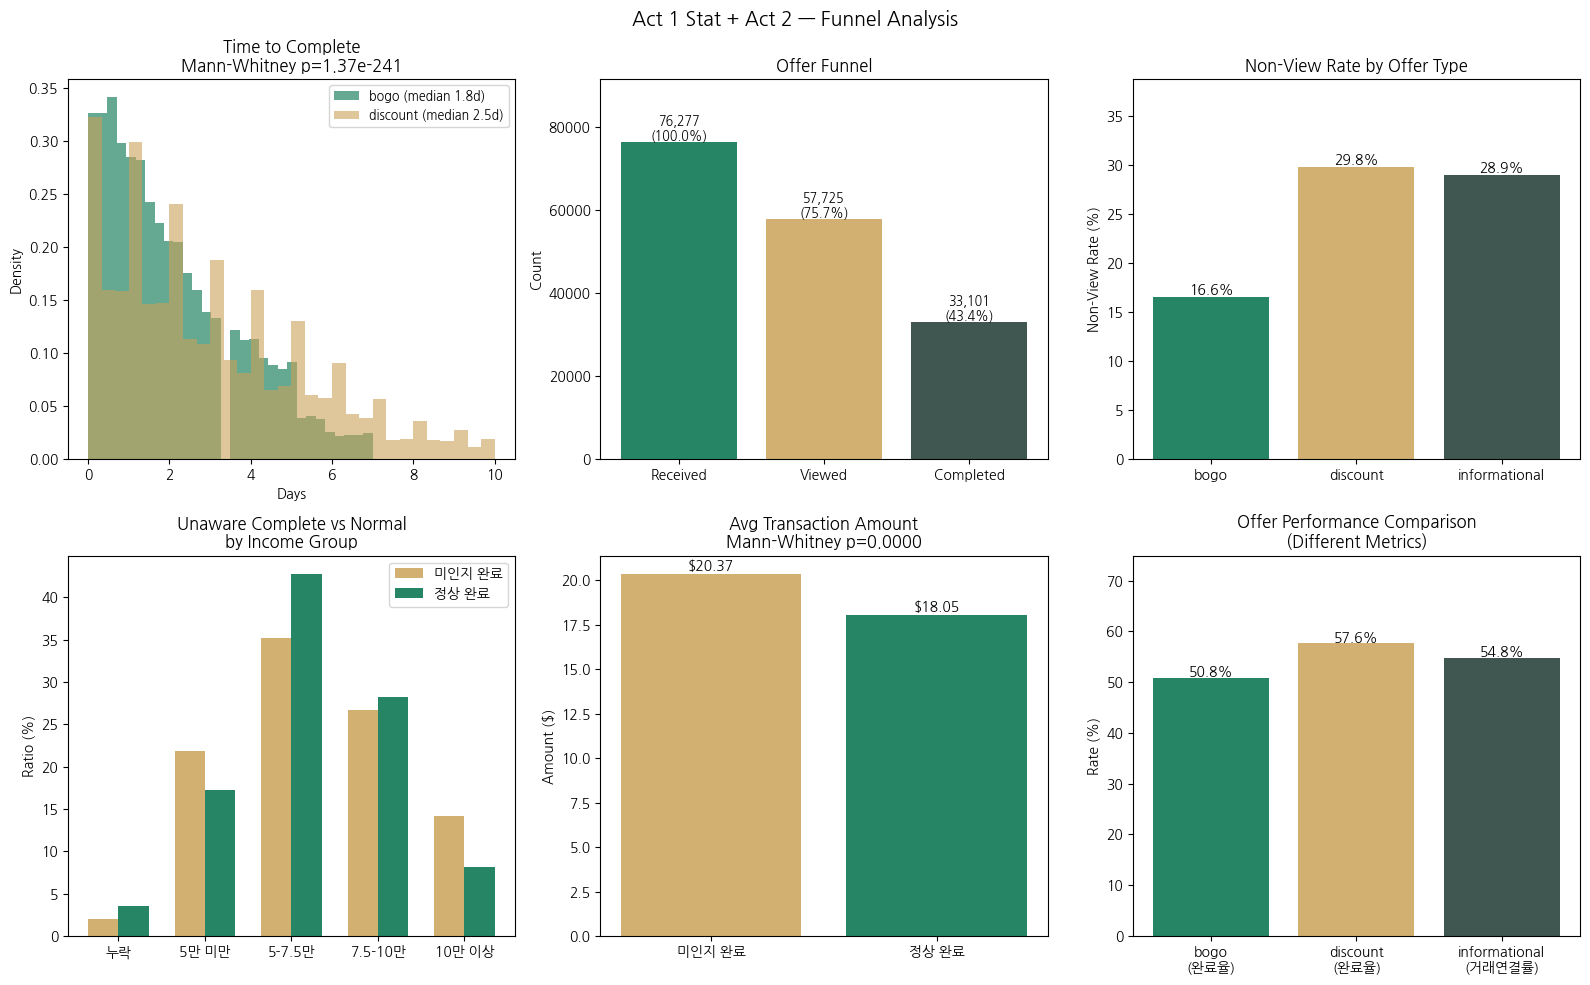

In [31]:
# stage2 시각화
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Act 1 Stat + Act 2 — Funnel Analysis', fontsize=14, fontweight='bold')

colors = ['#00704A', '#CBA258', '#1E3932', '#D4E9E2', '#006241', '#F2C75C']

# 차트 1: bogo vs discount 반응 시간 분포 (통계)
ax1 = axes[0, 0]
b_plot = (bogo_gap[bogo_gap <= 240] / 24)
d_plot = (disc_gap[disc_gap <= 240] / 24)
ax1.hist(b_plot, bins=30, alpha=0.6, color='#00704A',
         label=f'bogo (median {bogo_gap.median()/24:.1f}d)', density=True)
ax1.hist(d_plot, bins=30, alpha=0.6, color='#CBA258',
         label=f'discount (median {disc_gap.median()/24:.1f}d)', density=True)
ax1.set_title(f'Time to Complete\nMann-Whitney p={p_val:.2e}', fontweight='bold')
ax1.set_xlabel('Days')
ax1.set_ylabel('Density')
ax1.legend(fontsize=9)

# 차트 2: 퍼널 단계별 수치
ax2 = axes[0, 1]
stages = ['Received', 'Viewed', 'Completed']
vals = [total_received, total_viewed, total_completed]
bar_colors = ['#00704A', '#CBA258', '#1E3932']
bars = ax2.bar(stages, vals, color=bar_colors, alpha=0.85)
for bar, v, pct in zip(bars, vals, [100, total_viewed/total_received*100, total_completed/total_received*100]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'{v:,}\n({pct:.1f}%)', ha='center', fontsize=9)
ax2.set_title('Offer Funnel', fontweight='bold')
ax2.set_ylabel('Count')
ax2.set_ylim(0, max(vals) * 1.2)

# 차트 3: 오퍼 유형별 미열람률
ax3 = axes[0, 2]
nv_rates = []
otypes = ['bogo', 'discount', 'informational']
for ot in otypes:
    r = (funnel[funnel['offer_type'] == ot]['was_viewed'] == 0).mean() * 100
    nv_rates.append(r)
bars3 = ax3.bar(otypes, nv_rates, color=['#00704A', '#CBA258', '#1E3932'], alpha=0.85)
for bar, v in zip(bars3, nv_rates):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{v:.1f}%', ha='center', fontsize=10)
ax3.set_title('Non-View Rate by Offer Type', fontweight='bold')
ax3.set_ylabel('Non-View Rate (%)')
ax3.set_ylim(0, max(nv_rates) * 1.3)

# 차트 4: 미인지 완료 vs 정상 완료 소득 구간
ax4 = axes[1, 0]
inc_order = ['누락', '5만 미만', '5-7.5만', '7.5-10만', '10만 이상']
uw_vals = [uw_inc.get(i, 0) for i in inc_order]
aw_vals = [aw_inc.get(i, 0) for i in inc_order]
x = range(len(inc_order))
w = 0.35
ax4.bar([i - w/2 for i in x], uw_vals, w, label='미인지 완료', color='#CBA258', alpha=0.85)
ax4.bar([i + w/2 for i in x], aw_vals, w, label='정상 완료', color='#00704A', alpha=0.85)
ax4.set_xticks(list(x))
ax4.set_xticklabels(inc_order)
ax4.set_title('Unaware Complete vs Normal\nby Income Group', fontweight='bold')
ax4.set_ylabel('Ratio (%)')
ax4.legend()

# 차트 5: 미인지 완료 vs 정상 완료 평균 거래금액
ax5 = axes[1, 1]
labels5 = ['미인지 완료', '정상 완료']
values5 = [uw_tx.mean(), aw_tx.mean()]
bars5 = ax5.bar(labels5, values5, color=['#CBA258', '#00704A'], alpha=0.85)
for bar, v in zip(bars5, values5):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'${v:.2f}', ha='center', fontsize=10)
ax5.set_title(f'Avg Transaction Amount\nMann-Whitney p={p2:.4f}', fontweight='bold')
ax5.set_ylabel('Amount ($)')

# 차트 6: 오퍼 유형별 성과 비교 (완료율 vs 연결률)
ax6 = axes[1, 2]
labels6 = ['bogo\n(완료율)', 'discount\n(완료율)', 'informational\n(거래연결률)']
values6 = [bogo_cr, disc_cr, link_rate]
colors6 = ['#00704A', '#CBA258', '#1E3932']
bars6 = ax6.bar(labels6, values6, color=colors6, alpha=0.85)
for bar, v in zip(bars6, values6):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{v:.1f}%', ha='center', fontsize=10)
ax6.set_title('Offer Performance Comparison\n(Different Metrics)', fontweight='bold')
ax6.set_ylabel('Rate (%)')
ax6.set_ylim(0, max(values6) * 1.3)

plt.tight_layout()
plt.show()